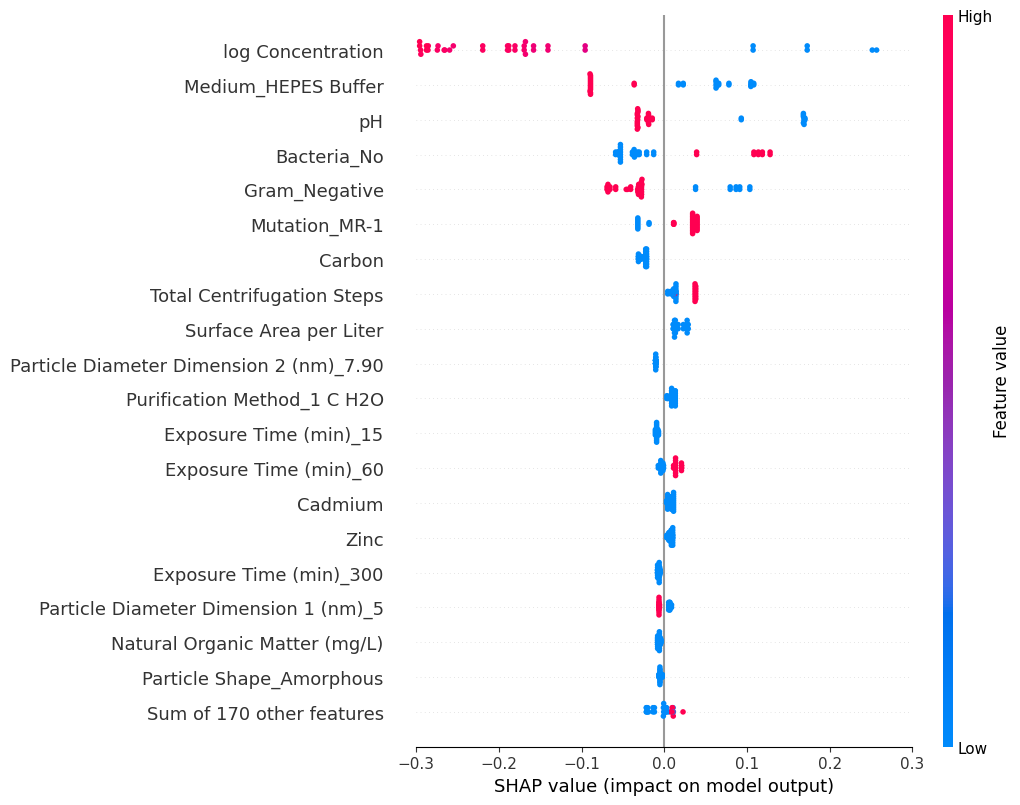

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
np.set_printoptions(precision=6)
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, ParameterGrid
import shap                         # SHAP library for explainability
import matplotlib.pyplot as plt     # for plotting
import pickle
import random
import os

# ----------------------------------------
# 0. set random seed for reproducibility
# ----------------------------------------
seed = 0
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ----------------------------------------
# 1. load and prepare data
# ----------------------------------------
def load_CSN_data():
    csv_path = '../CSN_Viability_Database_2025.csv'
    return pd.read_csv(csv_path)

# read CSV
CSN = load_CSN_data()

# drop unused columns
CSN = CSN.drop([
    'Example ID', 'Source', 'Figure ID', 'Data Provider',
    'PI', 'Date Received', 'Data Measurment Published',
    'Prior Exposure', 'Comments', 'Error'
], axis=1)

# one‐hot encode categorical variables
CSN_prepared = pd.get_dummies(CSN, dtype=int)

# create new engineered features
CSN_prepared['Surface Area per Liter'] = (
    CSN_prepared['Surface Area (NMC) (m2/g)']
    * CSN_prepared['Concentration (mg/L)']
)
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)

# log‐transform concentration
CSN_prepared['log Concentration'] = np.log10(
    CSN_prepared['Concentration (mg/L)'] + 1e-9
)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

# hold out last 38 samples as test set
CSN_new = CSN_prepared.iloc[-38:]
CSN_train = CSN_prepared.iloc[:-38]

# split into features and target
X_train = CSN_train.drop(['Viability_Fraction'], axis=1)
y_train = CSN_train['Viability_Fraction']
X_test  = CSN_new.drop(['Viability_Fraction'], axis=1)
y_test  = CSN_new['Viability_Fraction']

# ----------------------------------------
# 2. train XGBoost on original features
# ----------------------------------------

# define hyperparameter grid
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [7],
}

best_params = None
best_score = float('inf')
num_iterations = 10

# Monte Carlo CV for hyperparameter tuning
for params in ParameterGrid(param_grid):
    scores = []
    weights = []
    for _ in range(num_iterations):
        # random split between 10% and 30% for validation
        test_size = random.uniform(0.1, 0.3)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train.values, y_train.values,
            test_size=test_size,
            random_state=random.randint(0, 10000)
        )
        model_cv = XGBRegressor(
            objective='reg:squarederror',
            **params
        )
        model_cv.fit(X_tr, y_tr)
        y_val_pred = model_cv.predict(X_val)
        scores.append(mean_absolute_error(y_val, y_val_pred))
        weights.append(len(y_val))
    weighted_mae = np.average(scores, weights=weights)
    if weighted_mae < best_score:
        best_score = weighted_mae
        best_params = params

# train final model with best hyperparameters
xgb_original = XGBRegressor(
    objective='reg:squarederror',
    random_state=seed,
    **best_params
)
xgb_original.fit(X_train.values, y_train.values)

# ----------------------------------------
# 3. SHAP analysis on original features
# ----------------------------------------

# Initialize TreeExplainer, providing the training DataFrame so SHAP knows the feature names & background
explainer = shap.Explainer(xgb_original, X_train)

# Compute SHAP values by passing in the test DataFrame (not .values)
shap_values = explainer(X_test)

# 3a. Beeswarm plot: global feature importance
#    — no need for feature_names argument when shap_values carries them already
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.xlim(-0.3, 0.3)
#plt.title("SHAP Beeswarm Plot for Original Features")
plt.savefig("shap_beeswarm_MCCX.pdf", format='pdf', bbox_inches='tight')
plt.show()



In [17]:
'''
# 3b. Waterfall plot: local explanation for the first test instance
shap.plots.waterfall(shap_values[0], max_display=30)
plt.title("SHAP Waterfall Plot for Test Sample #0")
plt.show()
'''

'\n# 3b. Waterfall plot: local explanation for the first test instance\nshap.plots.waterfall(shap_values[0], max_display=30)\nplt.title("SHAP Waterfall Plot for Test Sample #0")\nplt.show()\n'